In [17]:
# TASK 1: Relation Types & Counts 
# Step 1: Identify all relation  types and how frequently they appear.
# Step 2: Load triples into an RDF graph.
# Step 3: Count each predicate type using SPARQL.
# Step 4: Evaluation.

# import libraries essential for task 1
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, OWL
from pathlib import Path
from IPython.display import display
import pandas as pd
import re

DATA_DIR = Path(r"C:\Users\sarih\ke-project\data")   # evaluator adjusts this folder
TRIPLE = DATA_DIR / "OREGANO_V2.1.tsv"
DISPLAY_PLOT = False   
TOP_N = 20

# define a function that checks each RDF nodes are consistent for URIs
def fragment(text: str) -> str:
    frag = (text or "").strip().lower()
    frag = re.sub(r"[^\w]+", "_", frag)
    frag = re.sub(r"_{2,}", "_", frag).strip("_")
    if not frag:
        frag = "relation"
    if not frag[0].isalpha():
        frag = "r_" + frag
    return frag

# Namespaces & RDF Graph for ABox/TBox separation 
# instance namespace
KG  = Namespace("http://example.org/oregano/kg/")  
# predicate namespace
ONT = Namespace("http://example.org/oregano/ontology/")  

# if the file is not present in the mentioned folder display the message
if not TRIPLE.exists():
    raise FileNotFoundError(f"Triplet file not found at: {TRIPLE.resolve()}")

# Construct a knowledge graph
g1 = Graph()
g1.bind("kg",  KG); g1.bind("ont", ONT)
g1.bind("rdfs", RDFS); g1.bind("owl", OWL)

# Load the RDF triples from the function 
valid_triple = 0

with TRIPLE.open("r", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")
        if len(parts) != 3:
            continue
        head, rel, tail = parts
        s1 = URIRef(KG  + fragment(head))
        p1 = URIRef(ONT + fragment(rel))
        o1 = URIRef(KG  + fragment(tail))
        g1.add((s1, p1, o1))
        valid_triple += 1

# run the loop for ontology use and rdflabel used to make it human readable
for _, p1, _ in g1:
    g1.add((p1, RDF.type, OWL.ObjectProperty))
    g1.add((p1, RDFS.label, Literal(str(p1).rsplit("/", 1)[-1])))

# SPARQL: Count predicate  
que = """
SELECT ?predicate (COUNT(*) AS ?count)
WHERE { ?s ?predicate ?o }
GROUP BY ?predicate
ORDER BY DESC(?count)
"""
result = g1.query(que)

# store the results in list by running the loop
rows1 = []
for row in result:
    pred_uri1 = str(row["predicate"])
    counts     = int(row["count"])
    label1    = pred_uri1.rsplit("/", 1)[-1]
    rows1.append((label1, counts, pred_uri1))

# Construct a table using Dataframe
df_relation = (
    pd.DataFrame(rows1, columns=["Relation Type", "Count", "predicate_uri"]).sort_values(["Count","Relation Type"], ascending=[False, True]).reset_index(drop=True)
)

# Validation 
total_counted = int(df_relation["Count"].sum())
print(f"Valid triples:    {valid_triple:,}")
print(f"SPARQL counted triples:  {total_counted:,}")
print("Match" if total_counted == valid_triple else "Mismatch")

unique_relation = df_relation.shape[0]
print(f"\nUnique relations: {unique_relation}")
print("\nTop 10")
display(df_relation.head(10))

# Optional bar plot
if DISPLAY_PLOT and not def_relation.empty:
    try:
        import matplotlib.pyplot as plt
        top = df_relation.head(TOP_N)
        plt.figure(figsize=(10, 5))
        plt.bar(top["Relation Type"], top["Count"])
        plt.xticks(rotation=60, ha="right")
        plt.title(f"Top {TOPK_PLOT} Relations by Count")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"(Plot skipped – matplotlib not available) {e}")

# Final Display & Runtime Summary 
print("\nFirst 25 rows:")
display(df_relation.head(25))


Valid triples:    823,005
SPARQL counted triples:  819,920
Mismatch

Unique relations: 20

Top 10


,Relation Type,Count,predicate_uri
0,decrease_efficacy,215222,http://example.org/oregano/ontology/decrease_e...
1,has_target,201912,http://example.org/oregano/ontology/has_target
2,has_side_effect,112532,http://example.org/oregano/ontology/has_side_e...
3,has_phenotype,87247,http://example.org/oregano/ontology/has_phenotype
4,acts_within,44865,http://example.org/oregano/ontology/acts_within
5,increase_efficacy,44114,http://example.org/oregano/ontology/increase_e...
6,has_effect,19160,http://example.org/oregano/ontology/has_effect
7,increase_effect,18999,http://example.org/oregano/ontology/increase_e...
8,causes_condition,16337,http://example.org/oregano/ontology/causes_con...
9,has_activity,12584,http://example.org/oregano/ontology/has_activity



First 25 rows:


,Relation Type,Count,predicate_uri
0,decrease_efficacy,215222,http://example.org/oregano/ontology/decrease_e...
1,has_target,201912,http://example.org/oregano/ontology/has_target
2,has_side_effect,112532,http://example.org/oregano/ontology/has_side_e...
3,has_phenotype,87247,http://example.org/oregano/ontology/has_phenotype
4,acts_within,44865,http://example.org/oregano/ontology/acts_within
5,increase_efficacy,44114,http://example.org/oregano/ontology/increase_e...
6,has_effect,19160,http://example.org/oregano/ontology/has_effect
7,increase_effect,18999,http://example.org/oregano/ontology/increase_e...
8,causes_condition,16337,http://example.org/oregano/ontology/causes_con...
9,has_activity,12584,http://example.org/oregano/ontology/has_activity


Summary for Task 1
Initial step required for Task 1 is to load the TSV file OREGANO V2.1 TSV file which contains the triples that are 
Subject, predicate, Object and construct an RDF graph using RDFlib. Namespaces are used in order to avoid repeated 
usage of long URIs in different places of code as per the requirement of Task 1 two Namespaces which are KG and ONT 
such as Instances and for Ontology to maintain a clean ABox/TBox separation. Each predicate in the files is declared
as an OWL ObjectProperty with a human readable format rdfs:lables. SPARQL query is used to group triples by predicate 
and also it is used to count the number of occurrences, and provide a table which displays the frequency of the relation 
types. Validation is required to ensure the counted total equals the number of triples loaded. A code snippet is added to 
compute coverage (first 5 and 10 relations) and a normalized entropy metric to assess distribution skew. For additional visualization
bar chart is added for the top-N relations is displayed. This code illustrates the principles of knowledge engineering by 
using relations as ontological properties and use SPARQL query for accuracy and analysis.

In [18]:
# TASK 2 : Node types & counts 
# STEP1: Count DISTINCT node IDs 
# STEP 2:  Read only column 0 for speed, strip blanks, drop one header row if present.
# STEP 3:  Rank table, total, runtime, top-k coverage, and a skew indicator.

# import libraries essential for task 2
from pathlib import Path
import time, math
import pandas as pd
from IPython.display import display

# Create the object for the path folder where the triplet file is available
DATA_DIR = Path(r"C:\Users\sarih\ke-project\data")  
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_DIR}")

# Add the files to the list to count the node and its types
FILES_NODE= [
    "ACTIVITY.tsv","COMPOUND.tsv","DISEASES.tsv","EFFECT.tsv","GENES.tsv",
    "INDICATION.tsv","PATHWAYS.tsv","PHENOTYPES.tsv","SIDE_EFFECT.tsv","TARGET.tsv"
]

DISPLAY_PLOT = False   # set True to see a quick bar chart of counts
TOP_N  = 12

# Used to filter the list to recognize the header used in the TSV files to avoid miscounting
head_token_used = {"id","identifier","code","name","label","uri","curie"}

# Check if the first cell is header and also match the header token or alphabet
def header(token: str) -> bool:
    t1 = (token or "").strip().lower()
    return (t1 in head_token_used) or t1.isalpha()
    
# Count the Unique IDs in the first column, skipping blanks and a header row
def count_the_nodes(file_path: Path) -> int:
    s1 = pd.read_csv(file_path, sep="\t", header=None, usecols=[0], dtype=str,on_bad_lines="skip", engine="python")[0].astype(str)
    # Clean the blank and also null rows
    s1 = s1.str.strip()
    s1= s1[s1.ne("") & s1.notna()]
    # Skip if the first row is header
    if len(s1) and header(s1.iloc[0]):
        s1 = s1.iloc[1:]
     # Count the Unique nodes
    return int(s1.nunique())

# Store the valid and missing files
rows1, missing_rows = [], []

# Loop through each file and count unique node IDs and handle missing files
for filename in FILES_NODE:
    filepath = DATA_DIR / filename
    if not filepath.exists():
        missing_rows.append((filename, "missing")) 
        continue
    try:
       # Count the unique nodes and store the results and log read errors
        rows1.append((filename.replace(".tsv",""), count_the_nodes(filepath)))
    except Exception as e1:
        missing_rows.append((filename, f"read error: {e1}"))

# Create a table according to the sorted occurrences of the node  
df_construct_nodes = (pd.DataFrame(rows1, columns=["Node Type", "Count"]).sort_values(["Count","Node Type"], ascending=[False, True]).reset_index(drop=True))

print("Node type counts (ranked):")
display(df_construct_nodes)

# Print any missing or unreadable files
if missing_rows:
    print("\nFiles not counted:")
    for name, why in missing_rows:
        print(f"  - {name}: {why}")
        
# Summarize the node types and the count of each node
total_node_types = int(df_construct_nodes.shape[0])
total_no_of_nodes = int(df_construct_nodes["Count"].sum())

print(f"\nTotals — types: {total_node_types}, nodes: {total_no_of_nodes:,}")

# Bar plot for top node types
if DISPLAY_PLOT and not df_construct_nodes.empty:
    try:
        import matplotlib.pyplot as plt
        top_nodes = df_construct_nodes.head(TOPK_PLOT)
        plt.figure(figsize=(10, 5))
        plt.bar(top_nodes["Node Type"], top["Count"])   
        plt.xticks(rotation=60, ha="right")
        plt.title(f"Top {TOP_N_PLOT} Node Types by Count")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"(Plot skipped) {e}")


Node type counts (ranked):


,Node Type,Count
0,COMPOUND,90869
1,GENES,35795
2,TARGET,22097
3,DISEASES,18334
4,PHENOTYPES,11606
5,SIDE_EFFECT,6061
6,INDICATION,2715
7,PATHWAYS,2129
8,EFFECT,172
9,ACTIVITY,79



Totals — types: 10, nodes: 189,857


Summary for Task 2
Task 2 is to identify the unique nodes which are present under each type of node in the OREGANO dataset given. 
Each node type will be identified from the different TSV files such as GENE.TSV,DISEASE.TSV and to find the unique 
node identifiers lets consider the first column from each file to return the unique code effectively. Functions 
like header() are used into detects the common keywords or tokens used in the file such as “id”, ”name” and skips 
them, to clean the spaces and to find the unique nodes count_the_nodes() is used. Looping is used to iterate to 
each node files and record the missing files and construct a DataFrame to display the types of nodes which are 
ranked by the no of occurrences. Finally, coverage_nodes() to compute the analytics which measures the top node 
types from the total and a normalized entropy to check the how the nodes are evenly distributed. For additional 
visualization bar chart is added for the top node type is displayed.

In [19]:
# TASK 3 : Node type & Relation type frequencies 
# STEP 1: Occurrences of SubjectType, Relation, ObjectType.
# STEP 2: RDFLib graph from TSV triples + node types from TSV files → SPARQL GROUP BY.
# STEP 3: Clean ABox/TBox separation & Counting
# STEP 4: Load/query no of times, triple-count, UNKNOWN-type rate, coverage, skew.

# import libraries essential for task 3
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, OWL
from pathlib import Path
from IPython.display import display
import pandas as pd
import re, time, math

# Create the object for the path folder where the triplet file is available
DATA_DIR = Path(r"C:\Users\sarih\ke-project\data")
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_DIR}")

# Create the object for the path folder where the triplet file is available
TRIPLE = DATA_DIR / "OREGANO_V2.1.tsv"
if not TRIPLE.exists():
    raise FileNotFoundError(f"Triple file not found: {TRIPLE}")

# Add the files to the list to count the node and its types
FILES_NODE= [
    "ACTIVITY.tsv","COMPOUND.tsv","DISEASES.tsv","EFFECT.tsv","GENES.tsv",
    "INDICATION.tsv","PATHWAYS.tsv","PHENOTYPES.tsv","SIDE_EFFECT.tsv","TARGET.tsv"
]
FILES_NODE+= [p1.name for p1 in DATA_DIR.glob("*.tsv")
               if p1.name.upper() != "OREGANO_V2.1.TSV" and p1.name not in FILES_NODE]

# Namespaces & RDF Graph for ABox/TBox separation 
# instance namespace
KG  = Namespace("http://example.org/oregano/kg/")  
# predicate namespace
ONT = Namespace("http://example.org/oregano/ontology/")  

# define a function that checks each RDF nodes are consistent for URIs
def fragment(text: str) -> str:
    t1 = (text or "").strip().lower()
    t1 = re.sub(r"[^\w]+", "_", t1)
    t1 = re.sub(r"_{2,}", "_", t).strip("_")
    if not t1: t1 = "item"
    if not t1[0].isalpha(): t1 = "r_" + t1
    return t1

def class_file(filename: str) -> URIRef:
    label1 = re.sub(r"[^\w]+", "_", Path(filename).stem.upper()).strip("_")
    return URIRef(ONT + label1)

def last_segment(uri_or_unknown: str) -> str:
    return uri_or_unknown if uri_or_unknown == "UNKNOWN" else uri_or_unknown.rsplit("/", 1)[-1]

# Used to filter the list to recognize the header used in the TSV files to avoid miscounting
HEAD_TOKEN_USED = {"id","identifier","code","name","label","uri","curie"}

# Check if the first cell is header and also match the header token or alphabet
def header(token: str) -> bool:
    t1 = (token or "").strip().lower()
    return (t1 in head_token_used) or t1.isalpha()

# Construct a knowledge graph 
g1 = Graph()
g1.bind("kg", KG); 
g1.bind("ont", ONT);
g1.bind("rdfs", RDFS); 
g1.bind("owl", OWL)

# Read the TSV triple file line by line
n_rows = 0
with TRIPLE.open("r", encoding="utf-8") as f:
    for line in f:
       #Split each line to head, relation and tail using tab separator
        parts = line.rstrip("\n").split("\t")
        if len(parts) != 3:
            continue
        h, r, t = parts; n_rows += 1
        # Convert each part into URI safe RDI nodes
        s = URIRef(KG  + fragment(h))
        p = URIRef(ONT + fragment(r))
        o = URIRef(KG  + fragment(t))

        # Add the triple (s1,p1,o1) into the RDF graph
        g1.add((s, p, o))

    # Predicates as ObjectProperties (labels for readability)
    for _, predicate, _ in g1:
        g1.add((predicate, RDF.type, OWL.ObjectProperty))
        g1.add((predicate, RDFS.label, Literal(last_segment(str(predicate)))))

# Checks the files are present
existing_file = [DATA_DIR/f for f in FILES_NODE if (DATA_DIR/f).exists()]
if not existing_file:
    print("No node TSVs found")

# Declare the class in ONT
for filepath in existing_file:
    ont_class = class_file(filepath.name)
    g1.add((ont_class, RDF.type, OWL.Class))
    g1.add((ont_class, RDFS.label, Literal(last_segment(str(ont_class)))))

    # Read the first column, remove the spaces and drop the null values
    s1 = pd.read_csv(filepath, sep="\t", header=None, usecols=[0], dtype=str,on_bad_lines="skip", engine="python")[0]
    s1 = s1.dropna().astype(str).str.strip()
    if len(s1) and header(s1.iloc[0]):
        # Skip the header row
        s1 = s1.iloc[1:]
    for node_id in s1.unique():
        if node_id:
            g1.add((URIRef(KG + fragment(node_id)), RDF.type, ont_class))

# SPARQL: S×R×O counts BIND
que = """
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
SELECT ?sTypeS ?predicateS ?oTypeS (COUNT(*) AS ?n)
WHERE {
  ?s ?p ?o.
  OPTIONAL { ?s rdf:type ?sType . }
  OPTIONAL { ?o rdf:type ?oType . }
  BIND(COALESCE(STR(?sType), "UNKNOWN") AS ?sTypeS)
  BIND(STR(?p)                           AS ?predicateS)
  BIND(COALESCE(STR(?oType), "UNKNOWN") AS ?oTypeS)
}
GROUP BY ?sTypeS ?predS ?oTypeS
ORDER BY DESC(?n)
"""
result = g1.query(que)

# Create Dataframe in readable format with labels and URIs
rows = []
for r in result:
    s_type_uri = str(r["sTypeS"])
    o_type_uri = str(r["oTypeS"])
    pred_uri   = str(r["predicateS"])
    count        = int(r["n"])
    rows.append((last_segment(s_type_uri), last_segment(pred_uri), last_segment(o_type_uri),count, s_type_uri, pred_uri, o_type_uri))

df_cross_table = (pd.DataFrame(rows,columns=["Subject Type","Relation Type","Object Type","Count",
             "subject_type_uri","predicate_uri","object_type_uri"]).sort_values(["Count","Subject Type","Relation Type","Object Type"],
              ascending=[False, True, True, True]).reset_index(drop=True))

# Group the specific roles by Subject only & Object only
df_subject_table = (df_cross_table.groupby(["Subject Type","Relation Type"], as_index=False)["Count"].sum().sort_values(["Subject Type","Count","Relation Type"],
                                 ascending=[True, False, True]))

df_object_table = (df_cross_table.groupby(["Object Type","Relation Type"], as_index=False)["Count"].sum().rename(columns={"Object Type":"Node Type"})
             .sort_values(["Node Type","Count","Relation Type"],ascending=[True, False, True]))

# Any role specific as Subject or Object
df_any1 = (pd.concat([df_subject_table.rename(columns={"Subject Type":"Node Type"}),
            df_object_table[["Node Type","Relation Type","Count"]] ], ignore_index=True).groupby(["Node Type","Relation Type"], as_index=False)["Count"].sum()
         .sort_values(["Node Type","Count","Relation Type"],ascending=[True, False, True]))

# Display the tables 
print("\nTop 15 (SubjectType, Relation, ObjectType) patterns:")
display(df_cross_table.head(15))

print("Subject-role aggregates (by total edges):")
display(df_subject_table.groupby("Subject Type", as_index=False)["Count"].sum().sort_values("Count", ascending=False).head(10))

print("Object-role aggregates (by total edges):")
display(df_object_table.groupby("Node Type", as_index=False)["Count"].sum().sort_values("Count", ascending=False).head(10))




Top 15 (SubjectType, Relation, ObjectType) patterns:


,Subject Type,Relation Type,Object Type,Count,subject_type_uri,predicate_uri,object_type_uri
0,owl#ObjectProperty,22-rdf-syntax-ns#type,UNKNOWN,98752,http://www.w3.org/2002/07/owl#ObjectProperty,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,UNKNOWN
1,UNKNOWN,DISEASE:16711,UNKNOWN,49375,UNKNOWN,http://example.org/oregano/ontology/DISEASE:16711,UNKNOWN
2,owl#Class,rdf-schema#label,UNKNOWN,20,http://www.w3.org/2002/07/owl#Class,http://www.w3.org/2000/01/rdf-schema#label,UNKNOWN
3,ACTIVITY,22-rdf-syntax-ns#type,owl#Class,10,http://example.org/oregano/ontology/ACTIVITY,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2002/07/owl#Class
4,COMPOUND,22-rdf-syntax-ns#type,owl#Class,10,http://example.org/oregano/ontology/COMPOUND,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2002/07/owl#Class
5,DISEASES,22-rdf-syntax-ns#type,owl#Class,10,http://example.org/oregano/ontology/DISEASES,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2002/07/owl#Class
6,EFFECT,22-rdf-syntax-ns#type,owl#Class,10,http://example.org/oregano/ontology/EFFECT,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2002/07/owl#Class
7,GENES,22-rdf-syntax-ns#type,owl#Class,10,http://example.org/oregano/ontology/GENES,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2002/07/owl#Class
8,INDICATION,22-rdf-syntax-ns#type,owl#Class,10,http://example.org/oregano/ontology/INDICATION,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2002/07/owl#Class
9,PATHWAYS,22-rdf-syntax-ns#type,owl#Class,10,http://example.org/oregano/ontology/PATHWAYS,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2002/07/owl#Class


Subject-role aggregates (by total edges):


,Subject Type,Count
12,owl#ObjectProperty,98752
10,UNKNOWN,49375
0,ACTIVITY,20
1,COMPOUND,20
2,DISEASES,20
3,EFFECT,20
4,GENES,20
5,INDICATION,20
6,PATHWAYS,20
7,PHENOTYPES,20


Object-role aggregates (by total edges):


,Node Type,Count
10,UNKNOWN,148147
11,owl#Class,100
0,ACTIVITY,10
1,COMPOUND,10
2,DISEASES,10
3,EFFECT,10
4,GENES,10
5,INDICATION,10
6,PATHWAYS,10
7,PHENOTYPES,10


Task 3 builds an RDF graph of the OREGANO triples and quantifies how often each SubjectType, Relation,ObjectsType pattern occurs. Initially, it loads
the triple such as head,relation,tail into a RDFLib graph, using the Namespace KG and relation IRIs which is predicate under a Namespace called ONT.
Next, it infers the classes of node by considering the first column of each node TSV for example GENE.TSV -> class “GENES” and declare rdf:type for 
those instances. Types are attached SPARQL query which counts all Subject,Predicate & Object combinations, and provide a rank table. Additionally 
group it by Subject role and object role to display which node types are most frequent occurrences in which relations. The table displays the top 
patterns for quick inspection.   

Top 12 edges:


,SubjectType,Relation,ObjectType,Count
0,COMPOUND,decrease_efficacy,COMPOUND,215222
1,COMPOUND,has_target,TARGET,201912
2,COMPOUND,has_side_effect,SIDE_EFFECT,112532
3,COMPOUND,22-rdf-syntax-ns#type,owl#Class,90869
4,DISEASES,has_phenotype,PHENOTYPES,87247
5,GENES,acts_within,PATHWAYS,44865
6,COMPOUND,increase_efficacy,COMPOUND,44114
7,GENES,22-rdf-syntax-ns#type,owl#Class,35795
8,TARGET,22-rdf-syntax-ns#type,owl#Class,22097
9,COMPOUND,has_effect,EFFECT,19160


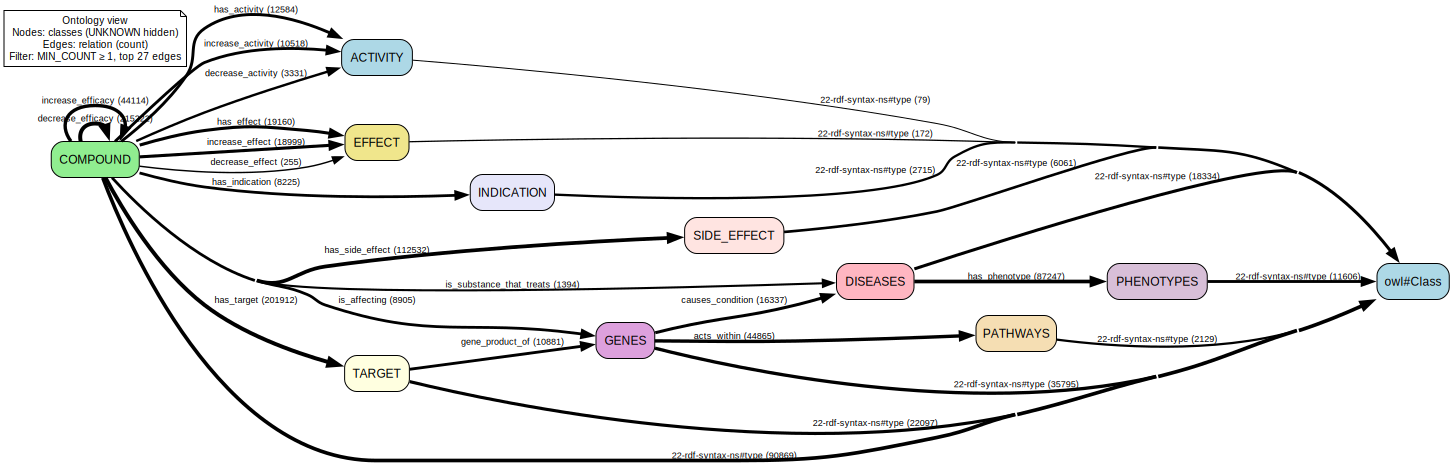

In [21]:
# TASK 4: Construct & Visualise Ontology 
#  STEP 1: ONT classes from node TSV filenames
#  STEP 2: ONT object properties from relation labels in OREGANO_V2.1.tsv
#  STEP 3: Class→relation→class edges inferred from typed node connections with counts
#  STEP 4: Visualise with Graphviz (labelled nodes & edges)

# import libraries essential for task 4
import os, re
from pathlib import Path
import pandas as pd
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, OWL
from graphviz import Digraph
from math import log1p
from IPython.display import display, SVG

# Create the object for the path folder where the triplet file is available
DATA_DIR = Path(r"C:\Users\sarih\ke-project\data")

# Create the object for the path folder where the triplet file is available
TRIPLE= DATA_DIR / "OREGANO_V2.1.tsv"
if not TRIPLE.exists():
    raise FileNotFoundError(f"Triples file not found at: {TRIPLE}")

# Help Graphviz be discoverable
os.environ["PATH"] += r";C:\Program Files\Graphviz\bin"

# Add the files to the list to count the node and its types
FILES_NODE = [
    "ACTIVITY.tsv","COMPOUND.tsv","DISEASES.tsv","EFFECT.tsv","GENES.tsv",
    "INDICATION.tsv","PATHWAYS.tsv","PHENOTYPES.tsv","SIDE_EFFECT.tsv","TARGET.tsv"
]
for p1 in DATA_DIR.glob("*.tsv"):
    if p1.name.upper() != "OREGANO_V2.1.TSV" and p1.name not in FILES_NODE:
        FILES_NODE.append(p1.name)

# Namespaces & RDF Graph for ABox/TBox separation 
# instance namespace
KG  = Namespace("http://example.org/oregano/kg/")
# predicate namespace
ONT = Namespace("http://example.org/oregano/ontology/")

# define a function that checks each RDF nodes are consistent for URIs
def fragment(text: str, for_relation=False) -> str:
    frag1 = (text or "").strip().lower()
    frag1 = re.sub(r"[^\w]+", "_", frag1)
    frag1 = re.sub(r"_{2,}", "_", frag1).strip("_")
    if not frag1:
        frag1 = "relation" if for_relation else "item"
    if not frag1[0].isalpha():
        frag1 = ("r_" if for_relation else "t_") + frag1
    return frag1

def class_file(fname: str) -> URIRef:
    label1 = Path(fname).stem.upper()
    label1 = re.sub(r"[^\w]+", "_", label1).strip("_")
    return URIRef(ONT + label1)

def last_segment(u1: str) -> str:
    return u1.rsplit("/", 1)[-1]

# Construct a knowledge graph
g1 = Graph()
g1.bind("kg", KG); g1.bind("ont", ONT); g1.bind("rdfs", RDFS); g1.bind("owl", OWL)

# Load triples & make predicates object properties
with TRIPLE.open("r", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")
        if len(parts) != 3:
            continue
        head, rel, tail = parts
        s = URIRef(KG + fragment(head))
        p = URIRef(ONT + fragment(rel, for_relation=True))
        o = URIRef(KG + fragment(tail))
        g1.add((s, p, o))
        g1.add((p, RDF.type, OWL.ObjectProperty))
        g1.add((p, RDFS.label, Literal(last_segment(str(p)))))

# Checks the files are present
existing_node_files = [DATA_DIR/f for f in FILES_NODE if (DATA_DIR/f).exists()]
if not existing_node_files:
    print("No node TSVs found; untyped nodes will appear as UNKNOWN in the diagram.")

# Declare the class in ONT
for filepath in existing_node_files:
    class1 = class_file(filepath.name)
    g1.add((class1, RDF.type, OWL.Class))
    g1.add((class1, RDFS.label, Literal(last_segment(str(class1)))))
    try:
        df_nodes = pd.read_csv(filepath, sep="\t", header=None, dtype=str, on_bad_lines="skip")
        ids = df_nodes[0].dropna().astype(str).drop_duplicates()
        for node_id in ids:
            g1.add((URIRef(KG + fragment(node_id)), RDF.type, class1))
    except Exception as e1:
        print(f"Could not read {filepath.name}: {e1}")

# SPARQL: S×R×O counts BIND
que = """
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
SELECT ?sTypeS ?predS ?oTypeS (COUNT(*) AS ?n)
WHERE {
  ?s ?p ?o .
  OPTIONAL { ?s rdf:type ?sType . }
  OPTIONAL { ?o rdf:type ?oType . }
  BIND(COALESCE(STR(?sType), "UNKNOWN") AS ?sTypeS)
  BIND(STR(?p)                           AS ?predS)
  BIND(COALESCE(STR(?oType), "UNKNOWN") AS ?oTypeS)
}
GROUP BY ?sTypeS ?predS ?oTypeS
ORDER BY DESC(?n)
"""
result = g1.query(que)

# Create Dataframe in readable format with labels and URIs
rows = []
for r in result:
    s_type_uri = str(r["sTypeS"])
    o_type_uri = str(r["oTypeS"])
    pred_uri   = str(r["predS"])
    count        = int(r["n"])    
    rows.append(("UNKNOWN" if s_type_uri == "UNKNOWN" else last_segment(s_type_uri),
        last_segment(pred_uri),"UNKNOWN" if o_type_uri == "UNKNOWN" else last_segment(o_type_uri),count ))

df_edges = (
    pd.DataFrame(rows, columns=["SubjectType", "Relation", "ObjectType", "Count"]).sort_values(["Count", "SubjectType", "Relation", "ObjectType"],
                 ascending=[False, True, True, True]).reset_index(drop=True))

# Display the tables
print("Top 12 edges:")
display(df_edges.head(12))

MAX_EDGES, MIN_COUNT = 200, 1
EDGE_FONT, NODE_FONT = "Arial", "Arial"
df_viz = df_edges.query(
    "Count >= @MIN_COUNT & SubjectType != 'UNKNOWN' & ObjectType != 'UNKNOWN'").head(MAX_EDGES)

# Edge width scales with log(count)
cmin, cmax = (int(df_viz["Count"].min()), int(df_viz["Count"].max())) if len(df_viz) else (1, 1)
def penwidth(n: int, lo=1.0, hi=4.0) -> str:
    if cmax == cmin:
        return f"{(lo + hi) / 2:.2f}"
    x = (log1p(n) - log1p(cmin)) / (log1p(cmax) - log1p(cmin))
    return f"{lo + x * (hi - lo):.2f}"

dot = Digraph("Ontology", format="svg")
dot.attr(rankdir="LR", concentrate="true", splines="spline")

# Nodes: classes
classes = sorted(set(df_viz["SubjectType"]) | set(df_viz["ObjectType"]))

# Define a simple palette of readable color names
color_palette = [
    "lightblue", "lightgreen", "lightpink", "khaki", "plum",
    "lavender", "wheat", "thistle", "mistyrose", "lightyellow"
]

# Assign colors in a repeating cycle
for i, c in enumerate(classes):
    fill_color = color_palette[i % len(color_palette)]  # cycle through colors
    dot.node(
        c,
        label=c,
        shape="box",
        style="rounded,filled",
        fillcolor=fill_color,
        fontname=NODE_FONT,
        fontsize="12"
    )

# Legend
legend = f"""Ontology view
Nodes: classes (UNKNOWN hidden)
Edges: relation (count)
Filter: MIN_COUNT ≥ {MIN_COUNT}, top {min(MAX_EDGES, len(df_viz))} edges"""
dot.node("_legend", label=legend, shape="note", fontsize="10", fontname=NODE_FONT)

# Edges: labelled with relation + count
for _, row in df_viz.iterrows():
    s, rel, o, n = row["SubjectType"], row["Relation"], row["ObjectType"], int(row["Count"])
    dot.edge(s, o, label=f"{rel} ({n})", fontname=EDGE_FONT, fontsize="9", penwidth=penwidth(n))

# Display inline SVG
svg_bytes = dot.pipe(format="svg")
display(SVG(svg_bytes))


Task 4 derives a trivial ontology and visualizes it as class level graph. It provides the ONT class directly from node TSV filenames (e.g., DISEASES.TSV -> class “DISEASES”)and treats relation labels from the triple file as ONT object properties, adding the labels which provides the readability to humans. Instances are related to the classes via rdf:type based on TSV.SPARQL query then aggregates edges into class infers relation that infers class counts. For visualization, the code filters to non-UNKNOWN types and the top edge, which draws a Graphviz diagram: classes become a circular box and each related edge is labelled with its relation and theoccurrences where thicker the edges those are most common related links. The diagram displays the  as SVG for properties to communicate sparsity and coverage

In [22]:
# Task 5 
# Step 1: First Order Logic Modelling  TPTP + human-readable .fol
# Step 2: Unary predicates for node types 
# Step 3: Binary predicates for relations (lowercase, safe)
# Step 4: Domain (Universe): U(x) ↔ (∨_i Class_i(x)) & all axioms guarded by U
# Step 5:  Domain/Range: top-k (by occurrences) class pairs per relation
# Step 6: Quantifiers chosen by coverage metrics are not printed

# import libraries essential for task 5
from pathlib import Path
from collections import Counter, defaultdict
from IPython.display import display, Markdown
import csv, re
import pandas as pd

# Create the object for the path folder where the triplet file is available
STUDENT_ID = 40498534
DATA_DIR = Path(r"C:\Users\sarih\ke-project\data")

# Create the object for the path folder where the triplet file is available
TRIPLE_TSV = DATA_DIR / "OREGANO_V2.1.tsv"
if not TRIPLE_TSV.exists():
    raise FileNotFoundError(f"Missing triples:{TRIPLE_TSV}")

# Add the files to the list to count the node and its types
FILES_NODE = [
    "ACTIVITY.tsv","COMPOUND.tsv","DISEASES.tsv","EFFECT.tsv","GENES.tsv",
    "INDICATION.tsv","PATHWAYS.tsv","PHENOTYPES.tsv","SIDE_EFFECT.tsv","TARGET.tsv"]

FILES_NODE += [p1.name for p1 in DATA_DIR.glob("*.tsv")
               if p1.name.upper() != "OREGANO_V2.1.TSV" and p1.name not in FILES_NODE]
# Limit of pairs per relation
TOPK_DOMAIN_RANGE = 5          
# Threshold for strong axioms
COVERAGE_STRONG = 0.95      
# Threshold for most axioms   
COVERAGE_MEDIUM = 0.50         

# define a function that checks each RDF nodes are consistent for URIs
def safe_sym(s1: str) -> str:
    s1 = (s1 or "").strip()
    s1 = re.sub(r"[^\w]+", "_", s1)
    s1 = re.sub(r"_{2,}", "_", s1).strip("_")
    if not s1:
        s1 = "p"
    if not s[0].isalpha():
        s1 = "p_" + s1
    return s1.lower()

def class_filename(filename: str) -> str:
    return re.sub(r"[^\w]+", "_", Path(filename).stem).strip("_")

def discover_node_paths(data_dir: Path, seeds: list[str]) -> list[Path]:
    out1, seen1 = [], set()
    for name in seeds:
        p1 = data_dir / name
        if p1.exists():
            out1.append(p1); seen1.add(p1.name)
    for p1 in data_dir.glob("*.tsv"):
        if p1.name.upper() == "OREGANO_V2.1.TSV":
            continue
        if p1.name not in seen1:
            out1.append(p1); seen1.add(p1.name)
    return out1

#  Build ID & Type 
def build_id1type(node_paths1: list[Path]) -> dict[str, str]:
    id1type = {}
    for p1 in node_paths1:
        classes = class_filename(p1.name)
        try:
            with p1.open("r", encoding="utf-8", errors="replace") as f:
                reader = csv.reader(f, delimiter="\t")
                first = None
                for rows in reader:
                    if rows and any(c1.strip() for c1 in row):
                        first = rows; break
                # if first cell looks like ID header, treat as Data Id
                if first:
                    c0 = first[0].strip().lower()
                    header = (c0 in {"id","identifier","code","name","label","uri","curie"}) or (c0.isalpha() and not any(ch.isdigit() for ch in c0))
                    if not header:
                        noid = first[0].strip()
                        if noid and noid not in id1type:
                            id1type[noid] = classes
                # consider rest of the rows
                for rows in reader:
                    if not rows: continue
                    noid = (rows[0] or "").strip()
                    if noid and noid not in id1type:
                        id1type[noid] = classes
        except Exception:
            # Ignore individual file errors to keep inline run clean
            pass
    return id1type

# Stream triples & stats 
def compute_stat(triple_tsv: Path, id1type: dict[str, str]):
    freq = Counter()
    subj_univ = defaultdict(set)    
    subj_with_relation = defaultdict(set)    
    relation_label_map = {}                  

    with triple_tsv.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 3:
                continue
            h, r, t = parts
            S = id1type.get(h, "Unknown")
            O = id1type.get(t, "Unknown")
            res = safe_sym(r)
            relation_label_map.setdefault(res, (r.strip() or res))
            freq[(S, res, O)] += 1
            subj_univ[S].add(h)
            subj_with_relation[(S, res)].add(h)

  # Collect unique classes/relations 
    classes, relations = set(), set()
    for (S, res, O), _ in freq.items():
        classes.update([S, O]); relations.add(res)

    # top-k subject and object pairs per relation
    pairs_by_relation = defaultdict(list)
    for (S, res, O), c in freq.items():
        if c > 0:
            pairs_by_relation[res].append((S, O, c))
    for res in pairs_by_relation:
        pairs_by_relation[res].sort(key=lambda x: x[2], reverse=True)

    coverage_rows = []
    for (S, res), subjset in subj_with_relation.items():
        denom = len(subj_univ.get(S, set()))
        part  = len(subjset)
        coverage   = (part / denom) if denom else 0.0
        coverage_rows.append({"SubjectType": S, "Relation": res, "Subjects": denom, "SubjectsWithR": part, "Coverage": coverage})

    return classes, relations, pairs_by_relation, coverage_rows, relation_label_map

# Emit TPTP + human FOL 
def emit_specs(classes, relations, pairs_by_relation, coverage_rows, relation_label_map):
    tptp1, fol1 = [], []

    # normalise class predicate names (lowercase, safe)
    raw_classes = sorted(c for c in classes if c != "Unknown")
    class_map = {c: safe_sym(c) for c in raw_classes}
    class_predicate = sorted(set(class_map.values()))

    # headers
    tptp1.append(f"% ECS8052 Task 5 — TPTP FOL (Student {STUDENT_ID})")
    fol1.append(f"ECS8052 Task 5 — FOL (Student {STUDENT_ID})\n")

    # Universe predicate
    fol1.append("Universe Predicate:")
    fol1.append(" U(x) //x is an OREGANO entity")
    if class_predicate:
        rhs_h = " ∨ ".join([f"{c}(x)" for c in class_predicate])
        rhs_t = " | ".join([f"{c}(X)" for c in class_predicate])
        fol1.append(f"  ∀x ( U(x) ↔ ({rhs_h}) )\n")
        tptp1.append(f"fof(universe_def, axiom, (! [X]: ( U(X) <=> ( {rhs_t} ) ) )).")
    else:
        fol1.append("No known classes found.\n")

    # Unary predicates(human doc only)
    fol1.append("Unary predicates(classes):")
    for c_raw in raw_classes:
        fol1.append(f"  {class_map[c_raw]}(x) // x is a {c_raw}")
    fol1.append("")

    # Binary predicates
    fol1.append("Binary predicates(relations):")
    for r in sorted(relations):
        human = relation_label_map.get(r, r)
        fol1.append(f"  {r}(x,y)  // {human}")
    fol1.append("")

    # Domain/Range axioms (top-k typed pairs)
    fol1.append("Domain/Range axioms:")
    def tptp1_imp_domain_range(r, pairs):
        rhs = " | ".join([f"({class_map[S]}(Y1) & {class_map[O]}(Y2))" for (S,O) in pairs])
        return f"fof(dom_ran_{r}, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & {r}(Y1,Y2)) => ( {rhs} ) ) ))."

    for r in sorted(relations):
        pairs = [(S,O) for (S,O,_) in pairs_by_relation.get(r, []) if S!="Unknown" and O!="Unknown"][:TOPK_DOMAIN_RANGE]
        if not pairs:
            fol1.append(f"  // {r}: no typed pairs observed (only Unknown).")
            continue
        rhs = " ∨ ".join([f"({class_map[S]}(x) ∧ {class_map[O]}(y))" for (S,O) in pairs])
        fol1.append(f"  ∀x∀y ( U(x) ∧ U(y) ∧ {r}(x,y) → {rhs} )")
        tptp1.append(tptp1_imp_domain_range(r, pairs))
    fol1.append("")

    # Coverage-based quantifiers no coverage metrics printed
    fol1.append("Quantified existence")
    for row in sorted(coverage_rows, key=lambda d: (d["SubjectType"], d["Relation"])):
        S_raw, r  = row["SubjectType"], row["Relation"]
        if S_raw == "Unknown":
            continue
        S = class_map.get(S_raw, safe_sym(S_raw))
        denom = int(row["Subjects"]); part = int(row["SubjectsWithR"])
        cov   = float(row["Coverage"])
        if denom == 0:
            continue
        if cov >= COVERAGE_STRONG:
            fol1.append(f"  ∀x ( U(x) ∧ {S}(x) → ∃y (U(y) ∧ {r}(x,y)) )")
            tptp1.append(f"fof(cov_strong_{S}_{r}, axiom, (! [X]: ( (U(X) & {S}(X)) => (? [Y]: (U(Y) & {r}(X,Y))) ) )).")
        elif cov >= COVERAGE_MEDIUM:
            fol1.append(f"  ∀x ( U(x) ∧ {S}(x) → ∃y (U(y) ∧ {r}(x,y)) )")
            tptp1.append(f"fof(cov_most_{S}_{r}, axiom, (! [X]: ( (U(X) & {S}(X)) => (? [Y]: (U(Y) & {r}(X,Y))) ) )).")
        elif part > 0:
            fol1.append(f"  ∃x∃y ( U(x) ∧ U(y) ∧ {S}(x) ∧ {r}(x,y) )")
            tptp1.append(f"fof(cov_exist_{S}_{r}, axiom, (? [X,Y]: ( U(X) & U(Y) & {S}(X) & {r}(X,Y) ) )).")

    # Join into strings to display
    tptp_text = "\n".join(tptp1)
    fol_text  = "\n".join(fol1)

    # Display inline 
    display(Markdown("<details><summary><b>Full TPTP output</b></summary>\n\n```\n" + tptp_text + "\n```\n</details>"))
    display(Markdown("<details><summary><b>Full human-readable FOL</b></summary>\n\n```\n" + fol_text + "\n```\n</details>"))
    return tptp_text, fol_text

# Collect all node tables
node_paths = discover_node_paths(DATA_DIR,FILES_NODE)
id1type = build_id1type(node_paths)
classes, relations, pairs_by_relation, coverage_rows, relation_label_map = compute_stat(TRIPLE_TSV, id1type)
tptp_text, fol_text = emit_specs(classes, relations, pairs_by_relation, coverage_rows, relation_label_map)



<details><summary><b>Full TPTP output</b></summary>

```
% ECS8052 Task 5 — TPTP FOL (Student 40498534)
fof(universe_def, axiom, (! [X]: ( U(X) <=> ( activity(X) | compound(X) | diseases(X) | effect(X) | genes(X) | indication(X) | pathways(X) | phenotypes(X) | side_effect(X) | target(X) ) ) )).
fof(dom_ran_acts_within, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & acts_within(Y1,Y2)) => ( (genes(Y1) & pathways(Y2)) ) ) )).
fof(dom_ran_causes_condition, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & causes_condition(Y1,Y2)) => ( (genes(Y1) & diseases(Y2)) ) ) )).
fof(dom_ran_decrease_activity, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & decrease_activity(Y1,Y2)) => ( (compound(Y1) & activity(Y2)) ) ) )).
fof(dom_ran_decrease_effect, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & decrease_effect(Y1,Y2)) => ( (compound(Y1) & effect(Y2)) ) ) )).
fof(dom_ran_decrease_efficacy, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & decrease_efficacy(Y1,Y2)) => ( (compound(Y1) & compound(Y2)) ) ) )).
fof(dom_ran_gene_product_of, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & gene_product_of(Y1,Y2)) => ( (target(Y1) & genes(Y2)) ) ) )).
fof(dom_ran_has_activity, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & has_activity(Y1,Y2)) => ( (compound(Y1) & activity(Y2)) ) ) )).
fof(dom_ran_has_effect, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & has_effect(Y1,Y2)) => ( (compound(Y1) & effect(Y2)) ) ) )).
fof(dom_ran_has_indication, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & has_indication(Y1,Y2)) => ( (compound(Y1) & indication(Y2)) ) ) )).
fof(dom_ran_has_phenotype, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & has_phenotype(Y1,Y2)) => ( (diseases(Y1) & phenotypes(Y2)) ) ) )).
fof(dom_ran_has_side_effect, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & has_side_effect(Y1,Y2)) => ( (compound(Y1) & side_effect(Y2)) ) ) )).
fof(dom_ran_has_target, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & has_target(Y1,Y2)) => ( (compound(Y1) & target(Y2)) ) ) )).
fof(dom_ran_increase_activity, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & increase_activity(Y1,Y2)) => ( (compound(Y1) & activity(Y2)) ) ) )).
fof(dom_ran_increase_effect, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & increase_effect(Y1,Y2)) => ( (compound(Y1) & effect(Y2)) ) ) )).
fof(dom_ran_increase_efficacy, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & increase_efficacy(Y1,Y2)) => ( (compound(Y1) & compound(Y2)) ) ) )).
fof(dom_ran_is_affecting, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & is_affecting(Y1,Y2)) => ( (compound(Y1) & genes(Y2)) ) ) )).
fof(dom_ran_is_substance_that_treats, axiom, (! [Y1,Y2]: ( (U(Y1) & U(Y2) & is_substance_that_treats(Y1,Y2)) => ( (compound(Y1) & diseases(Y2)) ) ) )).
fof(cov_exist_compound_decrease_activity, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & decrease_activity(X,Y) ) )).
fof(cov_exist_compound_decrease_effect, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & decrease_effect(X,Y) ) )).
fof(cov_exist_compound_decrease_efficacy, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & decrease_efficacy(X,Y) ) )).
fof(cov_exist_compound_has_activity, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & has_activity(X,Y) ) )).
fof(cov_exist_compound_has_code, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & has_code(X,Y) ) )).
fof(cov_exist_compound_has_effect, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & has_effect(X,Y) ) )).
fof(cov_exist_compound_has_indication, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & has_indication(X,Y) ) )).
fof(cov_exist_compound_has_side_effect, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & has_side_effect(X,Y) ) )).
fof(cov_most_compound_has_target, axiom, (! [X]: ( (U(X) & compound(X)) => (? [Y]: (U(Y) & has_target(X,Y))) ) )).
fof(cov_exist_compound_increase_activity, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & increase_activity(X,Y) ) )).
fof(cov_exist_compound_increase_effect, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & increase_effect(X,Y) ) )).
fof(cov_exist_compound_increase_efficacy, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & increase_efficacy(X,Y) ) )).
fof(cov_exist_compound_is_affecting, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & is_affecting(X,Y) ) )).
fof(cov_exist_compound_is_substance_that_treats, axiom, (? [X,Y]: ( U(X) & U(Y) & compound(X) & is_substance_that_treats(X,Y) ) )).
fof(cov_strong_diseases_has_phenotype, axiom, (! [X]: ( (U(X) & diseases(X)) => (? [Y]: (U(Y) & has_phenotype(X,Y))) ) )).
fof(cov_most_genes_acts_within, axiom, (! [X]: ( (U(X) & genes(X)) => (? [Y]: (U(Y) & acts_within(X,Y))) ) )).
fof(cov_exist_genes_causes_condition, axiom, (? [X,Y]: ( U(X) & U(Y) & genes(X) & causes_condition(X,Y) ) )).
fof(cov_strong_target_gene_product_of, axiom, (! [X]: ( (U(X) & target(X)) => (? [Y]: (U(Y) & gene_product_of(X,Y))) ) )).
```
</details>

<details><summary><b>Full human-readable FOL</b></summary>

```
ECS8052 Task 5 — FOL (Student 40498534)

Universe Predicate:
 U(x) //x is an OREGANO entity
  ∀x ( U(x) ↔ (activity(x) ∨ compound(x) ∨ diseases(x) ∨ effect(x) ∨ genes(x) ∨ indication(x) ∨ pathways(x) ∨ phenotypes(x) ∨ side_effect(x) ∨ target(x)) )

Unary predicates(classes):
  activity(x) // x is a ACTIVITY
  compound(x) // x is a COMPOUND
  diseases(x) // x is a DISEASES
  effect(x) // x is a EFFECT
  genes(x) // x is a GENES
  indication(x) // x is a INDICATION
  pathways(x) // x is a PATHWAYS
  phenotypes(x) // x is a PHENOTYPES
  side_effect(x) // x is a SIDE_EFFECT
  target(x) // x is a TARGET

Binary predicates(relations):
  acts_within(x,y)  // acts_within
  causes_condition(x,y)  // causes_condition
  decrease_activity(x,y)  // decrease_activity
  decrease_effect(x,y)  // decrease_effect
  decrease_efficacy(x,y)  // decrease_efficacy
  gene_product_of(x,y)  // gene_product_of
  has_activity(x,y)  // has_activity
  has_code(x,y)  // has_code
  has_effect(x,y)  // has_effect
  has_indication(x,y)  // has_indication
  has_phenotype(x,y)  // has_phenotype
  has_side_effect(x,y)  // has_side_effect
  has_target(x,y)  // has_target
  increase_activity(x,y)  // increase_activity
  increase_effect(x,y)  // increase_effect
  increase_efficacy(x,y)  // increase_efficacy
  is_affecting(x,y)  // is_affecting
  is_substance_that_treats(x,y)  // is_substance_that_treats

Domain/Range axioms:
  ∀x∀y ( U(x) ∧ U(y) ∧ acts_within(x,y) → (genes(x) ∧ pathways(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ causes_condition(x,y) → (genes(x) ∧ diseases(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ decrease_activity(x,y) → (compound(x) ∧ activity(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ decrease_effect(x,y) → (compound(x) ∧ effect(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ decrease_efficacy(x,y) → (compound(x) ∧ compound(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ gene_product_of(x,y) → (target(x) ∧ genes(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ has_activity(x,y) → (compound(x) ∧ activity(y)) )
  // has_code: no typed pairs observed (only Unknown).
  ∀x∀y ( U(x) ∧ U(y) ∧ has_effect(x,y) → (compound(x) ∧ effect(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ has_indication(x,y) → (compound(x) ∧ indication(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ has_phenotype(x,y) → (diseases(x) ∧ phenotypes(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ has_side_effect(x,y) → (compound(x) ∧ side_effect(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ has_target(x,y) → (compound(x) ∧ target(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ increase_activity(x,y) → (compound(x) ∧ activity(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ increase_effect(x,y) → (compound(x) ∧ effect(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ increase_efficacy(x,y) → (compound(x) ∧ compound(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ is_affecting(x,y) → (compound(x) ∧ genes(y)) )
  ∀x∀y ( U(x) ∧ U(y) ∧ is_substance_that_treats(x,y) → (compound(x) ∧ diseases(y)) )

Quantified existence
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ decrease_activity(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ decrease_effect(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ decrease_efficacy(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ has_activity(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ has_code(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ has_effect(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ has_indication(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ has_side_effect(x,y) )
  ∀x ( U(x) ∧ compound(x) → ∃y (U(y) ∧ has_target(x,y)) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ increase_activity(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ increase_effect(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ increase_efficacy(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ is_affecting(x,y) )
  ∃x∃y ( U(x) ∧ U(y) ∧ compound(x) ∧ is_substance_that_treats(x,y) )
  ∀x ( U(x) ∧ diseases(x) → ∃y (U(y) ∧ has_phenotype(x,y)) )
  ∀x ( U(x) ∧ genes(x) → ∃y (U(y) ∧ acts_within(x,y)) )
  ∃x∃y ( U(x) ∧ U(y) ∧ genes(x) ∧ causes_condition(x,y) )
  ∀x ( U(x) ∧ target(x) → ∃y (U(y) ∧ gene_product_of(x,y)) )
```
</details>

Task 5 converts observed KG structure into a safe first-order logic specification, provide output as both TPTP and a human-readable FOL text. 
It first takes classes from node TSVs and relations from the triple, ensures the names into safe predicates.Unary predicates encode classes; 
binary predicates encode relations. A universe predicate U(x) is defined equivalently as the disjunction of all class predicates, and every 
axiom is protected by U to scope quantification to KG entities. For each relation, the code selects the top-k considered SubjectClass, ObjectClass 
pairs and expose domain-and-range inferences stating that whenever the relation holds, the edge belongs to one of those class pairs. It also extracts 
existence-style axioms direct by observed coverage as strong/medium/evidence without printing the metrics. The final output provides both a machine-oriented TPTP block and a readable FOL counterpart, giving a generalization of the KG.


In [24]:
# Task 6 

# import libraries essential for task 6
from pathlib import Path
import csv, re
from collections import Counter
import pandas as pd
import networkx as nx
from IPython.display import display, HTML

# Optional dependencies 
use_igraph = False
try:
    import igraph as ig
    use_igraph = True
except Exception:
    pass

try:
    import community as community_louvain
    has_louvain = True
except Exception:
    has_louvain = False

try:
    from pyvis.network import Network
    has_pyvis = True
except Exception:
    has_pyvis = False

#  Create the object for the path folder where the triplet file is available
STUDENT_ID = 40498354
DATA_DIR   = Path(r"C:\Users\sarih\ke-project\data")

# Create the object for the path folder where the triplet file is available
TRIPLES = DATA_DIR / "OREGANO_V2.1.tsv"
if not TRIPLES.is_file():
    raise FileNotFoundError(f"Triples not found: {TRIPLES}")

# Add the files to the list to count the node and its types
FILES_NODE = [
    "ACTIVITY.tsv","COMPOUND.tsv","DISEASES.tsv","EFFECT.tsv","GENES.tsv",
    "INDICATION.tsv","PATHWAYS.tsv","PHENOTYPES.tsv","SIDE_EFFECT.tsv","TARGET.tsv"]

TOP_PAGERANK = 100
K_CORE_K     = 5
MAX_NODES    = 4000
MAX_EDGES    = 8000

#  Build ID & Type
def build_id1type(data_dir: Path, file_list: list) -> dict[str, str]:
    id1type = {}
    for filename in file_list:
        ntype = Path(filename).stem.capitalize()
        filepath = data_dir / filename
        if not filepath.is_file():
            continue

        with filepath.open("r", encoding="utf-8", errors="replace") as f:
            reader = csv.reader(f, delimiter="\t")
            first = None
            for row in reader:
                if row and any(c.strip() for c in row):
                    first = row
                    break

            if first:
                c0 = (first[0] or "").strip().lower()
                header = (
                    c0 in {"id", "identifier", "code", "name", "label", "uri", "curie"}
                    or (c0.isalpha() and not any(ch.isdigit() for ch in c0))
                )
                if not header:
                    node_id = (first[0] or "").strip()
                    if node_id:
                        id1type[node_id] = ntype

            for rows in reader:
                if not rows:
                    continue
                node_id = (rows[0] or "").strip()
                if node_id:
                    id1type[node_id] = ntype

    return id1type

def safe_labels(s1: str) -> str:
    s1 = (s1 or "").strip()
    s1 = re.sub(r"\s+", " ", s1)
    return s1[:120] if len(s1) > 120 else s1

# Stream triples 
Id1type = build_id1type(DATA_DIR, FILES_NODE)
index, rev = {}, []

def get_index(noid: str) -> int:
    if noid not in index:
        index[noid] = len(rev)
        rev.append(noid)
    return index[noid]

edges, relation_counter = [], Counter()
with TRIPLE.open("r", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")
        if len(parts) != 3:
            continue
        h, r, t = parts
        u, v = get_index(h), get_index(t)
        edges.append((u, v, r))
        relation_counter[r] += 1

# Build graph
G1 = nx.DiGraph()
G1.add_nodes_from(range(len(rev)))
for u, v, r in edges:
    if G1.has_edge(u, v):
        G1[u][v]["relations"].add(r)
        G1[u][v]["w"] += 1
    else:
        G1.add_edge(u, v, relations={r}, w=1)

nx.set_node_attributes(G1, {i: id1type.get(noid, "Unknown") for i, noid in enumerate(rev)}, "type")
nx.set_node_attributes(G1, {i: rev[i] for i in range(len(rev))}, "label")

#  Centrality + k-core 
pr1 = nx.pagerank(G1, alpha=0.85, weight="w")
top_pr_nodes = [n for n, _ in sorted(pr1.items(), key=lambda kv: kv[1],reverse=True)[:TOP_PAGERANK]]
Gu = G1.to_undirected(reciprocal=False)
core_num = nx.core_number(Gu)
core_nodes = [n for n, k in core_num.items() if k >= K_CORE_K]
seed_set = set(top_pr_nodes) | set(core_nodes)

# Subgraph
nodes_select, edges_select = set(), set()
for s1 in seed_set:
    nodes_select.add(s1)
    for nbr in G1.successors(s1):
        nodes_select.add(nbr); edges_select.add((s1, nbr))
    for nbr in G1.predecessors(s1):
        nodes_select.add(nbr); edges_select.add((nbr, s1))
    if len(nodes_select) >= MAX_NODES:
        break

if len(nodes_select) > MAX_NODES:
    keep = set(sorted(nodes_select, key=lambda n: pr1.get(n, 0), reverse=True)[:MAX_NODES])
    edges_select = {(u, v) for (u, v) in edges_select if u in keep and v in keep}
    nodes_select = keep

if len(edges_select) > MAX_EDGES:
    edges_select = set(list(edges_select)[:MAX_EDGES])

H = G1.edge_subgraph(list(edges_select)).copy()
H.add_nodes_from(nodes_select)

# Community detection
comm = {}
if use_igraph:
    mapping = {n: i for i, n in enumerate(H.nodes())}
    invmap  = {i: n for n, i in mapping.items()}
    ig_edges = [(mapping[u], mapping[v]) for (u, v) in H.edges()]
    gi = ig.Graph(n=len(mapping), edges=ig_edges, directed=True)
    giu = gi.as_undirected()
    try:
        import leidenalg as la
        part = la.find_partition(giu, la.RBConfigurationVertexPartition)
        for cid, members in enumerate(part):
            for m in members: comm[invmap[m]] = cid1
    except Exception:
        part = giu.community_multilevel()
        for cid1, members in enumerate(part):
            for m in members: comm[invmap[m]] = cid1
else:
    if has_louvain:
        part = community_louvain.best_partition(H.to_undirected(), weight="w", random_state=STUDENT_ID)
        comm = part
    else:
        lp1 = nx.algorithms.community.asyn_lpa_communities(H.to_undirected(), seed=STUDENT_ID, weight="w")
        for cid, members in enumerate(lp1):
            for m in members: comm[m] = cid1

nx.set_node_attributes(H, comm, "community")

# Interactive PyVis visual 
if not has_pyvis:
    print("PyVis not installed — skipping visual. Install with: pip install pyvis")
else:
    net = Network(height="800px", width="100%", directed=True, notebook=True, bgcolor="white")
    net.barnes_hut(gravity=-2000, central_gravity=0.25, spring_length=130, spring_strength=0.02, damping=0.1)

    # Use basic color names instead of hex codes
    palette = [
        "red", "blue", "green", "orange", "purple",
        "pink", "brown", "gray", "yellow", "cyan"
    ]

    def color_for(node):
        c = H.nodes[node].get("community", -1)
        return palette[c % len(palette)] if isinstance(c, int) and c >= 0 else "lightgray"

    max_pr = max(pr1.values()) if pr1 else 1.0
    for n in H.nodes():
        label = rev[n]
        ntype = H.nodes[n].get("type","Unknown")
        pr_val = pr1.get(n, 0.0)
        title = f"<b>{safe_labels(label)}</b><br>Type: {ntype}<br>Community: {H.nodes[n].get('community','?')}"
        size = 8 + 25 * (pr_val / max_pr)
        net.add_node(n, label=label[:30], title=title, color=color_for(n), size=size)

    for u, v in H.edges():
        rels = sorted(list(H[u][v]["relations"]))
        title = "<br>".join(rels)
        width = min(1 + H[u][v].get("w",1) ** 0.5, 8)
        net.add_edge(u, v, title=title, width=width, arrows="to")

    net.cdn_resources = "in_line"
    html_str = net.generate_html(notebook=True)
    display(HTML(html_str))


Task 6 builds and discovers an interactive subgraph of the OREGANO knowledge graph. It uses a path, and few dependencies which are optional such as igraph, Louvain, PyVis, and adjustable TOP_PAGERANK, K_CORE_K, MAX_NODES/EDGES.Node tables are read guarded to map original IDs to types. Triple are run once into integer-indexed nodes and a weighted DiGraph; parallel edges are combined while maintain a set of predicates and edge multiplies. 
PageRank identifies global hubs, and an undirected k-core fetches a keystone. Seeds are the union of top-PR and core nodes; a bounded 1-hop expansion forms a manageable subgraph, shape to size caps. Communities are found via a cascade: Leiden (igraph) → Louvain → asynchronous label propagation fallback. The code summarizes relation mix, node-type counts, and top PageRank nodes, then provide an interactive PyVis view: node size ∝ PageRank, color by community, width ∝ multiplicity, with predicate tooltips. Lastly, brief structural stats and commentary guide interpretation of hubs, modularity, and bridges.
